In [8]:
import random
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from typing import List, Tuple

- There are N agents interacting repeatedly in discrete rounds.
- Each ordered pair of agents (i, j) has a memory of the last M earnings agent i received when interacting with j.
- From this memory, agent i computes the average recent earning.
- Before playing, each agent decides whether it is willing to interact with the other agent based on the difference of the average recent earning with respect to this agent. This creates the first parameter, a threshold. Please note that if the threshold is positive once separated they will never interact again. In the first five rounds of the game agents always interact. The threshold is part of the strategy of the agent.
- An interaction occurs only if both agents are willing.
- If they interact, the agents play a Prisoner’s Dilemma game. (see matrix below)
- Each agent chooses Cooperate (C) or Defect (D) according to its strategy
- Payoffs are assigned according to the game’s payoff matrix.
- Each agent stores its own payoff from the interaction in its memory with that partner (keeping only the most recent M). You can use the deque(maxlen=M) from collections. By appending a new element to it it removes the old ones.
- Agents accumulate total earnings during the round.
- After each round, agents may adopt the strategy or the threshold of a more successful agent (one with higher earnings).
- The process repeats for many rounds to observe the evolution of strategies and interaction patterns.
- Implement different strategies:
    - Always defect
    - Always cooperative
    - Probabilistic
    - Tit for tat (starting with C)
- Plot the fraction of different strategies as function of game rounds


In [6]:
PAYOFF = {
    ('C','C'): (3,3),
    ('C','D'): (0,5),
    ('D','C'): (5,0),
    ('D','D'): (1,1),
}

In [102]:
class Player:
    def __init__(self, id, interacting_ids, strategy, thr, memory=5):
        self.id = id
        self.strategy = strategy
        self.thr = thr
        self.memory_size = memory
        self.score_history = deque(maxlen=10)
        # Memory: payoff history per opponent
        self.memory = {
            j: deque(maxlen=memory) for j in interacting_ids
        }
        
        # Last observed opponent actions (for TFT)
        self.last_actions = {j: 'C' for j in interacting_ids}
        self.inactive_counter = {j: 0 for j in interacting_ids}
        self.total_score = 0

    def willing_to_play(self, j, cooldown=10):
        mem = self.memory[j]
        
        # If recently inactive long enough → retry
        if self.inactive_counter[j] >= cooldown:
            return True
        
        if len(mem) < 5:
            return True
        
        avg = np.mean(mem)
        return avg >= self.thr

    def finalize_round(self):
        self.score_history.append(self.total_score)
        
    def choose_action(self, j):
        if self.strategy == 'allc':
            return 'C'
        
        elif self.strategy == 'alld':
            return 'D'
        
        elif self.strategy == 'tft':
            return self.last_actions[j]
        
        elif self.strategy == 'prob':
            return 'C' if random.random() < 0.5 else 'D'
        
        else:
            raise ValueError("Unknown strategy")

    def update_after_round(self, j, payoff, opponent_action):
        self.memory[j].append(payoff)
        self.last_actions[j] = opponent_action
        self.total_score += payoff

    def reset_score(self):
        self.total_score = 0

In [109]:
def play_round(players):
    N = len(players)
    
    for i in range(N):
        for j in range(i+1, N):
            p1 = players[i]
            p2 = players[j]
            
            if p1.willing_to_play(j) and p2.willing_to_play(i):
                a1 = p1.choose_action(j)
                a2 = p2.choose_action(i)
                
                payoff1, payoff2 = PAYOFF[(a1, a2)]
                
                p1.update_after_round(j, payoff1, a2)
                p2.update_after_round(i, payoff2, a1)
                
                # reset inactivity
                p1.inactive_counter[j] = 0
                p2.inactive_counter[i] = 0

            else:
                # increase inactivity
                p1.inactive_counter[j] += 1
                p2.inactive_counter[i] += 1
                
def recent_performance(player):
    if not player.score_history:
        return 0
    return np.mean(player.score_history)
            
def update_strategies(players, chance_to_imitate=0.2, which='best'):
    if which == 'all':
        for p in players:
            better = [q for q in players if q.total_score > p.total_score]
            coin = np.random.rand()
            if better and coin < chance_to_imitate:
                role_model = random.choice(better)
                p.strategy = role_model.strategy
                p.thr = role_model.thr
    elif which == 'best':
        best_player = max(players, key=lambda p: recent_performance(p))
        
        for p in players:
            if p is best_player:
                continue  # skip self-copy
            
            coin = np.random.rand()
            
            if coin < chance_to_imitate:
                p.strategy = best_player.strategy
                p.thr = best_player.thr
                
    elif which == 'random':
        for p in players:
            other = random.choice(players)
            if other is p:
                continue
            
            coin = np.random.rand()
            if coin < chance_to_imitate:
                p.strategy = other.strategy
                p.thr = other.thr
    else:
        raise ValueError("Unknown imitation type")
        

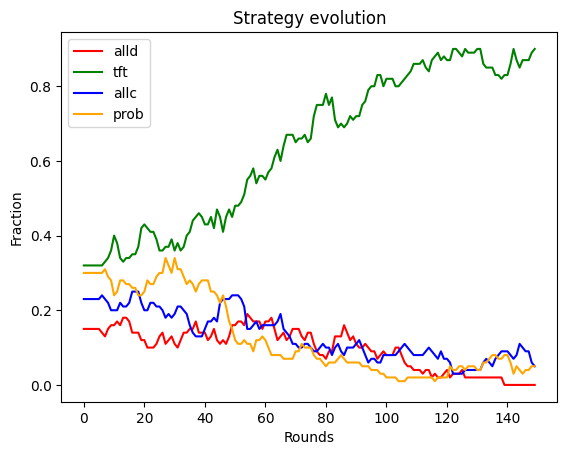

Probs in last step with all 4 strategies: {'tft': 0.82, 'allc': 0.09, 'prob': 0.07, 'alld': 0.02}


In [115]:
def simulate(players, rounds, 
             strategy_update_interval=10, 
             chance_to_imitate=0.2,
             which='best'):
    history = []
    
    for r in range(rounds):
        for p in players:
            p.reset_score()
        
        play_round(players)
        for p in players:
            p.finalize_round()
            
        if r % strategy_update_interval == 0 and r > 5:
            update_strategies(players, chance_to_imitate=chance_to_imitate, 
                              which=which)
        # track fractions
        counts = {}
        for p in players:
            counts[p.strategy] = counts.get(p.strategy, 0) + 1
        
        for k in counts:
            counts[k] /= len(players)
        
        history.append(counts)
    
    return history


# -------------------------
# Plotting
# -------------------------
def plot_history(history):
    strategy_colors ={
        'allc': 'blue',
        'alld': 'red',
        'tft': 'green',
        'prob': 'orange'
    }
    strategies = set()
    for h in history:
        strategies.update(h.keys())
    
    for s in strategies:
        vals = [h.get(s, 0) for h in history]
        plt.plot(vals, label=s, color=strategy_colors.get(s, 'black'))
    
    plt.xlabel("Rounds")
    plt.ylabel("Fraction")
    plt.title("Strategy evolution")
    plt.legend()
    plt.show()
    
    # plot interaction matrix in last step when all 4 strategies are alive
    idx = 0
    strategies = ['allc', 'alld', 'tft', 'prob']
    for i, item in enumerate(history):
        if len(item) == 4:
            idx = i
        else:
            break
    print(f"Probs in last step with all 4 strategies: {history[idx]}")
    


# -------------------------
# Initialization
# -------------------------
def initialize_players(N):
    strategies = ['allc', 'alld', 'tft', 'prob']
    
    players = []
    for i in range(N):
        interacting_ids = [j for j in range(N) if j != i]
        strategy = random.choice(strategies)
        thr = 2 #random.uniform(0, 3)  # tune this
        
        players.append(Player(i, interacting_ids, strategy, thr))
    
    return players



N = 100
ROUNDS = 150

players = initialize_players(N)
history = simulate(players, ROUNDS, 
                   strategy_update_interval=1, 
                   chance_to_imitate=0.1,
                   which='random')
plot_history(history)

In [27]:
np.roll(a, -1)

array([1, 2, 3, 4, 5, 6, 7, 8, 9, 0])